In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import pairwise_distances



# PCA data from week5_2

In [ ]:
PROCESSED = '/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/personality/'
personality = '/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/city_features_new.parquet'

# PCA DATA
pca_data = pd.read_parquet(PROCESSED + 'city_features_pca_new.parquet')
city_features_orig = pd.read_parquet(personality)

In [ ]:
city_features_orig.head()

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,personality__pets,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz
0,AB Edmonton,1,4.500000,4.5,0.000000,6,6.000000,1.000000,2.000000,0.00000,...,0.000000,4.333333,1.632993,6,6,0.833333,0.166667,5.0,5.000000,5.0
1,AMBLER,1,3.000000,3.0,0.000000,9,9.000000,1.000000,4.000000,1.00000,...,0.000000,3.000000,1.825742,10,9,0.400000,0.300000,2.0,2.000000,2.0
2,ARDMORE,1,3.000000,3.0,0.000000,8,8.000000,1.000000,4.000000,0.00000,...,0.000000,3.000000,1.772811,8,8,0.250000,0.375000,12.0,12.000000,12.0
3,AVON,1,3.500000,3.5,0.000000,24,24.000000,0.000000,4.000000,0.00000,...,0.000000,3.416667,1.471960,24,24,0.291667,0.166667,37.0,37.000000,37.0
4,Abington,169,3.550296,3.5,0.999472,4829,28.573964,0.804734,4.248521,0.12426,...,0.017751,3.458971,1.621949,5033,3695,0.417445,0.225909,5693.0,40.091549,545.0


In [ ]:
print(f'PCA data shape: {pca_data.shape}')
print(f'Original features shape: {city_features_orig.shape}')
print(f'\nColumns (PCA): {pca_data.columns.tolist()}')
print(f'\nFirst rows (PCA):')
print(pca_data.head(2))

PCA data shape: (1416, 29)
Original features shape: (1416, 75)

Columns (PCA): ['city', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28']

First rows (PCA):
          city       PC1       PC2       PC3       PC4       PC5       PC6  \
0  AB Edmonton -2.713805  0.947698  2.094812  0.987331 -0.350031  0.121215   
1       AMBLER -4.133327  1.949012  2.484345  0.906389  0.862437  0.108707   

        PC7      PC8       PC9  ...      PC19      PC20      PC21      PC22  \
0  0.542903 -0.52727  0.128335  ... -1.720562 -0.336406  0.699037 -0.570859   
1 -1.815822  0.30451 -0.239711  ... -0.289169 -0.571101 -0.311844 -0.577863   

       PC23      PC24      PC25      PC26      PC27      PC28  
0 -1.211072 -0.781047 -1.957704  0.678490 -1.453648 -0.236959  
1 -0.623959 -0.188315 -0.212911 -0.174655 -0.316013  1.073175  

[2 rows x 29

##Filtering of cities
Cities with < 70 and > 1043 businesses add noise to personalities

In [ ]:
MIN_BUSINESSES = 70
MAX_BUSINESSES = 1043

# Filter cities by business count range
mask = (
    (city_features_orig['n_businesses'] >= MIN_BUSINESSES) &
    (city_features_orig['n_businesses'] <= MAX_BUSINESSES)
)

# Apply filtering
cities_filtered = pca_data[mask].copy()
cities_orig_filtered = city_features_orig[mask].copy()

# Reset index to avoid misalignment
cities_filtered = cities_filtered.reset_index(drop=True)
cities_orig_filtered = cities_orig_filtered.reset_index(drop=True)

# Extract city names
city_names = cities_orig_filtered['city']

# Extract PCA features for clustering
X = cities_filtered.drop(columns=['city'], errors='ignore').values
pc_columns = [f'PC{i}' for i in range(1, 11)]
X = cities_filtered[pc_columns].values

# Reporting
original_n = len(pca_data)
filtered_n = len(cities_filtered)
removed_n = original_n - filtered_n

print(f'Original cities: {original_n}')
print(f'After filtering ({MIN_BUSINESSES} <= n_businesses <= {MAX_BUSINESSES}): {filtered_n}')
print(f'Removed: {removed_n} cities ({removed_n/original_n:.1%})')

print('\nBusiness count statistics after filtering:')
print(cities_orig_filtered['n_businesses'].describe())

print(f'\nSamples (city_names length): {len(city_names)}')
print(f'Clustering input shape (X): {X.shape}')

print('\nSample city names:')
print(city_names[:5].tolist())

Original cities: 1416
After filtering (70 <= n_businesses <= 1043): 219
Removed: 1197 cities (84.5%)

Business count statistics after filtering:
count     219.000000
mean      237.027397
std       187.427146
min        70.000000
25%       111.500000
50%       170.000000
75%       292.000000
max      1043.000000
Name: n_businesses, dtype: float64

Samples (city_names length): 219
Clustering input shape (X): (219, 10)

Sample city names:
['Abington', 'Alton', 'Ambler', 'Antioch', 'Apollo Beach']


The 84.5% removed is due to a filtering decision, not a model error.

we used the next block to identify the best min max values to obtain better silhouttes values

In [ ]:
results = []

for n_pcs in [5, 8, 10, 12, 15]:

    X_sub = X[:, :n_pcs]

    for k in [4, 5]:

        kmeans = KMeans(n_clusters=k, random_state=42)

        labels = kmeans.fit_predict(X_sub)

        sil = silhouette_score(X_sub, labels)

        results.append({
            'n_pcs': n_pcs,
            'k': k,
            'silhouette': sil
        })

pd.DataFrame(results).sort_values('silhouette', ascending=False)

,n_pcs,k,silhouette
0,5,4,0.268662
2,8,4,0.239011
1,5,5,0.232093
4,10,4,0.214304
8,15,4,0.214304
6,12,4,0.214304
3,8,5,0.208857
5,10,5,0.206355
7,12,5,0.206355
9,15,5,0.206355


Histograma de n_businesses + umbrales de filtro

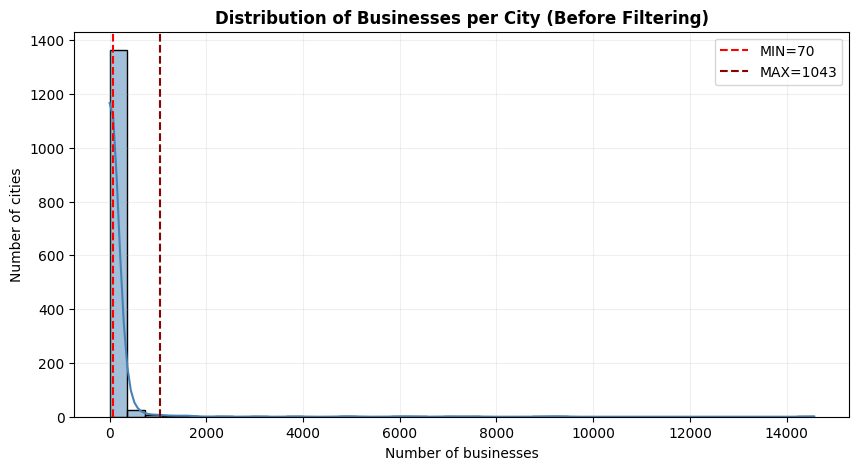

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(city_features_orig['n_businesses'], bins=40, kde=True, color='steelblue')
plt.axvline(MIN_BUSINESSES, color='red', linestyle='--', label=f'MIN={MIN_BUSINESSES}')
plt.axvline(MAX_BUSINESSES, color='darkred', linestyle='--', label=f'MAX={MAX_BUSINESSES}')
plt.title('Distribution of Businesses per City (Before Filtering)', fontsize=12, fontweight='bold')
plt.xlabel('Number of businesses')
plt.ylabel('Number of cities')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

this filtering strategy is justified and methodologically sound for your clustering objective. The histogram shows an extremely right-skewed distribution: most cities concentrate at low-to-medium business counts, while a small number of mega-cities extend to several thousand businesses. Without filtering, those extreme cities would dominate PCA variance and K-Means distance calculations, causing clusters to reflect mainly city size instead of commercial identity.

Using:

MIN = 70 removes sparse/noisy cities with unstable commercial profiles.
MAX = 1043 excludes extreme metropolitan outliers while preserving large but still comparable urban ecosystems.

This produces a more homogeneous analytical space where clusters reflect differences in dining culture, lifestyle, nightlife, wellness, and engagement patterns rather than raw scale alone.

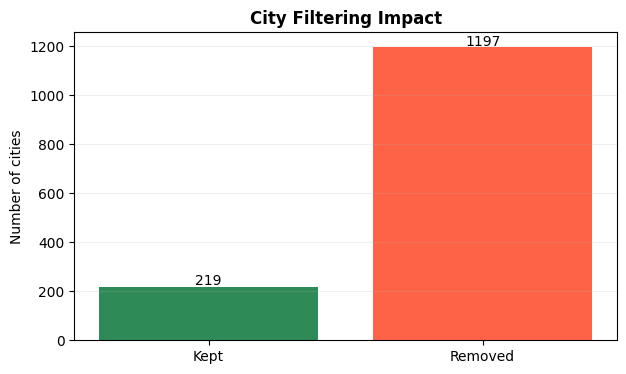

Kept: 15.5% | Removed: 84.5%


In [ ]:
kept_n = filtered_n
removed_n_local = original_n - filtered_n

plt.figure(figsize=(7,4))
bars = plt.bar(['Kept', 'Removed'], [kept_n, removed_n_local], color=['seagreen', 'tomato'])
plt.title('City Filtering Impact', fontsize=12, fontweight='bold')
plt.ylabel('Number of cities')

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 5, f'{int(h)}', ha='center')

plt.grid(axis='y', alpha=0.2)
plt.show()

print(f"Kept: {kept_n/original_n:.1%} | Removed: {removed_n_local/original_n:.1%}")

This filtering decision had a significant impact on dataset coverage loss. As mentioned previously, 1,197 cities were removed, representing 84.5% of the original dataset.

This high removal rate is considered a deliberate trade-off. Although a large portion of the original cities was excluded, the remaining 219 cities within the [70, 1043] business range were considered more suitable for the purpose of identifying city archetypes through clustering. The rationale is that the improvement in cluster quality and interpretability within this subset justifies the reduction in overall city coverage. In other words, the analysis prioritizes more meaningful and less outlier-biased clustering, even if it is applied to a smaller universe of cities.

#PARAMETERS SWEEP

#K-MEANS PARAMETER SWEEP
testing with k's from 2 to 12


In [ ]:
kmeans_results = []
K_range = range(2, 13)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)

    kmeans_results.append({
        'k': k,
        'inertia': inertia,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
        'model': kmeans,
        'labels': labels
    })

    print(f"k={k:2d} | Inertia: {inertia:10.1f} | Silhouette: {silhouette:.3f} | DB: {davies_bouldin:.3f} | CH: {calinski_harabasz:.1f}")

kmeans_df = pd.DataFrame(kmeans_results)

k= 2 | Inertia:      281.6 | Silhouette: 0.540 | DB: 1.046 | CH: 113.9
k= 3 | Inertia:      229.7 | Silhouette: 0.255 | DB: 1.343 | CH: 93.9
k= 4 | Inertia:      189.3 | Silhouette: 0.215 | DB: 1.259 | CH: 90.9
k= 5 | Inertia:      168.9 | Silhouette: 0.208 | DB: 1.330 | CH: 82.5
k= 6 | Inertia:      157.8 | Silhouette: 0.168 | DB: 1.346 | CH: 73.4
k= 7 | Inertia:      146.3 | Silhouette: 0.165 | DB: 1.318 | CH: 68.4
k= 8 | Inertia:      139.3 | Silhouette: 0.146 | DB: 1.488 | CH: 62.8
k= 9 | Inertia:      132.1 | Silhouette: 0.158 | DB: 1.534 | CH: 59.1
k=10 | Inertia:      123.5 | Silhouette: 0.161 | DB: 1.371 | CH: 57.6
k=11 | Inertia:      114.2 | Silhouette: 0.172 | DB: 1.188 | CH: 57.4
k=12 | Inertia:      109.9 | Silhouette: 0.162 | DB: 1.248 | CH: 54.7


The validation metrics show that k=2 produces the strongest statistical separation, achieving the highest silhouette score (0.540), the lowest Davies–Bouldin index (1.046), and the highest Calinski–Harabasz score (113.9). However, this solution mainly captures a coarse split between highly specialized cities and the broader urban majority. As k increases, inertia decreases steadily, indicating improved compactness, but silhouette and CH scores gradually decline, suggesting weaker cluster separation and increasing overlap between city profiles. Therefore, although larger k values reduce within-cluster variance, they trade statistical purity for more semantically nuanced and actionable urban archetypes.

###K-Means parameter sweep results

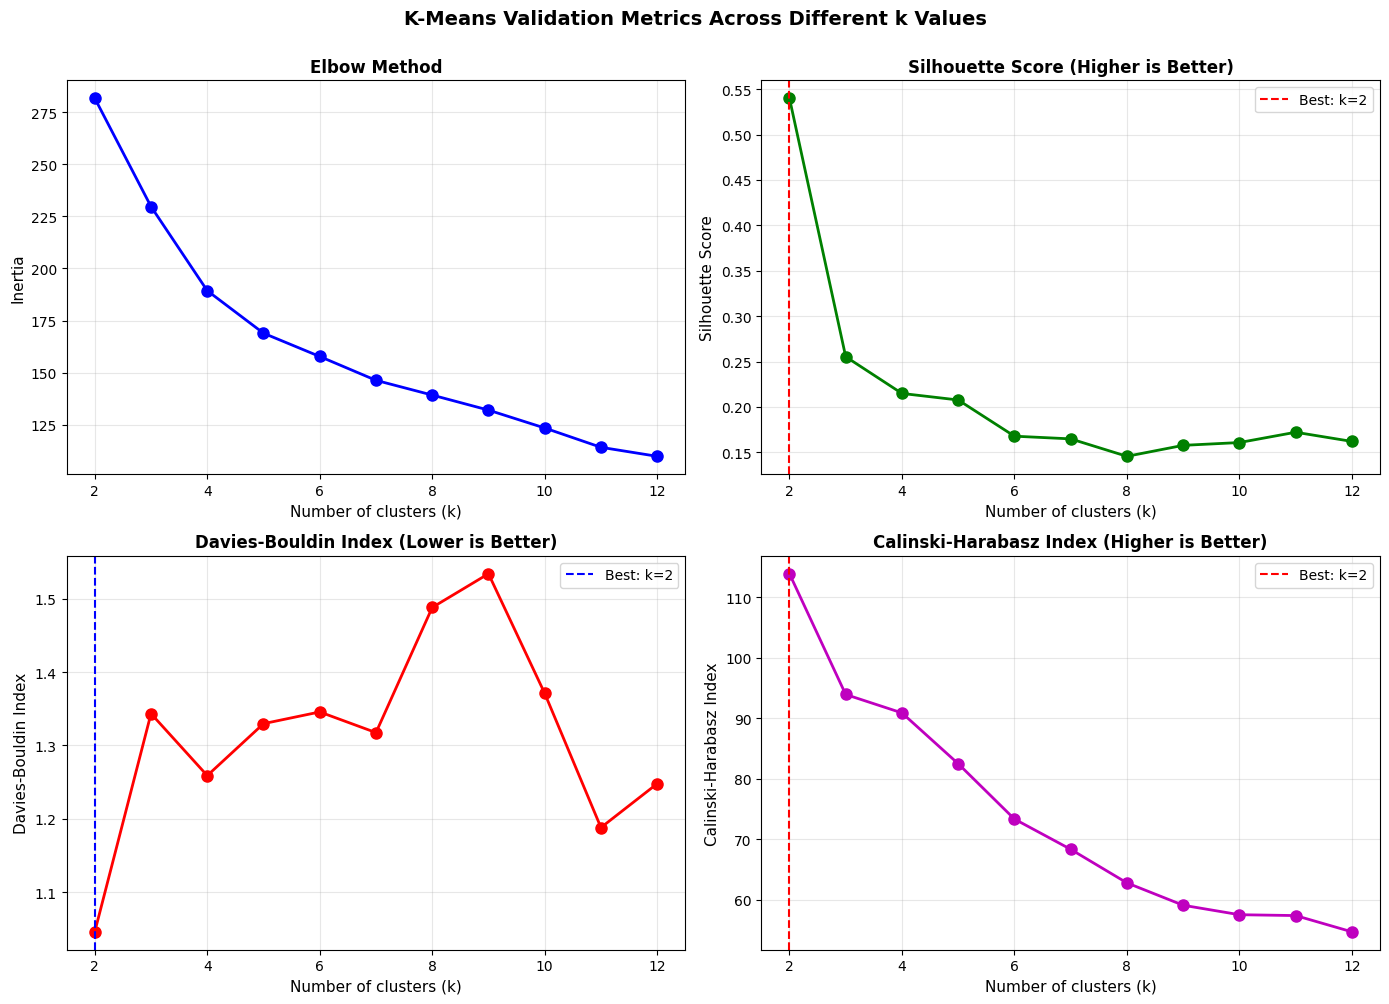


VALIDATION TABLE
 k    inertia  silhouette  davies_bouldin  calinski_harabasz
 2 281.646174    0.540073        1.045826         113.895131
 3 229.685083    0.255275        1.343430          93.941447
 4 189.330198    0.214826        1.258890          90.900117
 5 168.939835    0.207614        1.329721          82.505420
 6 157.773450    0.167732        1.345708          73.360525
 7 146.339106    0.164774        1.317525          68.361880
 8 139.264250    0.145546        1.488206          62.813537
 9 132.057790    0.157629        1.534211          59.118919
10 123.467854    0.160718        1.371056          57.554156
11 114.213424    0.172076        1.188047          57.413313
12 109.888769    0.161958        1.247872          54.727783


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow plot (Inertia)
axes[0, 0].plot(kmeans_df['k'], kmeans_df['inertia'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of clusters (k)', fontsize=11)
axes[0, 0].set_ylabel('Inertia', fontsize=11)
axes[0, 0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Silhouette score (max = 1 es mejor)
axes[0, 1].plot(kmeans_df['k'], kmeans_df['silhouette'], 'go-', linewidth=2, markersize=8)
max_silhouette_k = kmeans_df.loc[kmeans_df['silhouette'].idxmax(), 'k']
axes[0, 1].axvline(max_silhouette_k, color='red', linestyle='--', label=f'Best: k={int(max_silhouette_k)}')
axes[0, 1].set_xlabel('Number of clusters (k)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Davies-Bouldin (lower is better)
axes[1, 0].plot(kmeans_df['k'], kmeans_df['davies_bouldin'], 'ro-', linewidth=2, markersize=8)
min_db_k = kmeans_df.loc[kmeans_df['davies_bouldin'].idxmin(), 'k']
axes[1, 0].axvline(min_db_k, color='blue', linestyle='--', label=f'Best: k={int(min_db_k)}')
axes[1, 0].set_xlabel('Number of clusters (k)', fontsize=11)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Calinski-Harabasz (higher is better)
axes[1, 1].plot(kmeans_df['k'], kmeans_df['calinski_harabasz'], 'mo-', linewidth=2, markersize=8)
max_ch_k = kmeans_df.loc[kmeans_df['calinski_harabasz'].idxmax(), 'k']
axes[1, 1].axvline(max_ch_k, color='red', linestyle='--', label=f'Best: k={int(max_ch_k)}')
axes[1, 1].set_xlabel('Number of clusters (k)', fontsize=11)
axes[1, 1].set_ylabel('Calinski-Harabasz Index', fontsize=11)
axes[1, 1].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('K-Means Validation Metrics Across Different k Values', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VALIDATION TABLE")
print("="*80)
print(kmeans_df[['k', 'inertia', 'silhouette', 'davies_bouldin', 'calinski_harabasz']].to_string(index=False))

This graph shows better results with k=2 but as mentioned before is not the best for recommendation thus we explore a bit deeper with other k's

### best k with different criteria

k=2 is stadistically better but not accionable for recommendation, that's why we do another analysis:

In [ ]:
best_k_silhouette = kmeans_df.loc[kmeans_df['silhouette'].idxmax(), 'k']
best_k_db = kmeans_df.loc[kmeans_df['davies_bouldin'].idxmin(), 'k']

print(f"\nBest k by Silhouette: {int(best_k_silhouette)} (score: {kmeans_df.loc[kmeans_df['k'] == best_k_silhouette, 'silhouette'].values[0]:.3f})")
print(f"Best k by Davies-Bouldin: {int(best_k_db)} (score: {kmeans_df.loc[kmeans_df['k'] == best_k_db, 'davies_bouldin'].values[0]:.3f})")

# Usar silhouette como criterio principal
OPTIMAL_K = int(best_k_silhouette)
best_kmeans_result = kmeans_df[kmeans_df['k'] == OPTIMAL_K].iloc[0]
kmeans_model = best_kmeans_result['model']
kmeans_labels = best_kmeans_result['labels']

print(f"\n✓ Selected k = {OPTIMAL_K} for further analysis")


Best k by Silhouette: 2 (score: 0.540)
Best k by Davies-Bouldin: 2 (score: 1.046)

✓ Selected k = 2 for further analysis


k=2 = better statistical separation
k=4 = better interpretability for recommendation

We explore k=4 and k=5 as "semantic k" as they produce more clusters without degrading metrics scores too much (silhoutte, inertia,etc)

In [ ]:
OPTIMAL_K = 2      # better for silhouette/DB
SEMANTIC_K = 4     # better for recommendation archetypes

print("=" * 70)
print(f"Metric-optimal k: {OPTIMAL_K}  →  silhouette={kmeans_df.loc[kmeans_df['k']==OPTIMAL_K,'silhouette'].values[0]:.3f}")
print(f"Semantic k:       {SEMANTIC_K}  →  silhouette={kmeans_df.loc[kmeans_df['k']==SEMANTIC_K,'silhouette'].values[0]:.3f}")
print("=" * 70)
print()
print("k=2 produces 23 vs 196 city split — separates mega-cities from the rest.(re-run to visualize it)")
print("k=4 loses silhouette but produces actionable traveler archetypes.")
print()
print("Decision: use SEMANTIC_K=4 for recommendation system profiling.")
print("          OPTIMAL_K=2 is documented as the statistical baseline.")

# Re-fit with semantic k for all downstream analysis
kmeans_model = kmeans_df.loc[kmeans_df['k'] == SEMANTIC_K, 'model'].values[0] #to observe clusters k=2, we change semantic to optimal
kmeans_labels = kmeans_df.loc[kmeans_df['k'] == SEMANTIC_K, 'labels'].values[0]
print(f"\nCluster sizes at k={SEMANTIC_K}:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} cities")

Metric-optimal k: 2  →  silhouette=0.540
Semantic k:       4  →  silhouette=0.215

k=2 produces 23 vs 196 city split — separates mega-cities from the rest.(re-run to visualize it)
k=4 loses silhouette but produces actionable traveler archetypes.

Decision: use SEMANTIC_K=4 for recommendation system profiling.
          OPTIMAL_K=2 is documented as the statistical baseline.

Cluster sizes at k=4:
  Cluster 0: 71 cities
  Cluster 1: 9 cities
  Cluster 2: 53 cities
  Cluster 3: 86 cities


Although k=2 achieved the highest silhouette and Davies–Bouldin scores, the resulting clustering primarily separated a small group of highly distinctive cities from the rest of the dataset, producing limited practical value for recommendation and profiling tasks. In contrast, k=4 generated more balanced and semantically interpretable urban-commercial archetypes, separating cities into distinct lifestyle-oriented groups related to casual dining, upscale social activity, brunch-oriented commerce, and engagement intensity. While the silhouette score decreased compared to the statistical optimum, the k=4 solution provided richer and more actionable city profiles for the recommendation system, making it a better tradeoff between geometric compactness and semantic interpretability.

We chose k=4 because it gives more interpretable and actionable city archetypes for the recommendation system.
Although k=2 has better statistical scores (higher silhouette), it mostly creates a coarse split (distinctive cities vs. the rest), which is less useful for profiling.
With k=4, cluster separation is weaker but the groups are richer in meaning (lifestyle/commercial patterns), making them better for downstream recommendations.

In [ ]:
for cluster_id in range(4):

    cities = city_names[kmeans_labels == cluster_id]

    print(f'\nCluster {cluster_id}:')
    print(cities.tolist())


Cluster 0:
['Alton', 'Antioch', 'Arnold', 'Belleville', 'Bensalem', 'Berlin', 'Bridgeton', 'Bristol', 'Brookhaven', 'Brownsburg', 'Burlington', 'Camden', 'Chalmette', 'Cinnaminson', 'Clementon', 'Clifton Heights', 'Collinsville', 'Deptford', 'Drexel Hill', 'Ewing', 'Florissant', 'Folsom', 'Gallatin', 'Glassboro', 'Granite City', 'Gretna', 'Harleysville', 'Harvey', 'Hatfield', 'Hazelwood', 'Hermitage', 'Hudson', 'Kenner', 'La Vergne', 'Lansdowne', 'Levittown', 'Madison', 'Maple Shade', 'Marrero', 'Maryland Heights', 'Mooresville', 'Morrisville', 'Mount Holly', 'Mount Juliet', 'New Castle', 'New Port Richey', 'Newark', 'Old Hickory', 'Plainfield', 'Plant City', 'Port Richey', 'Pottstown', 'Quakertown', 'Richboro', 'Royersford', 'Ruskin', 'Seffner', 'Sherwood Park', 'Sicklerville', 'Smyrna', 'St Albert', 'St. Albert', 'Swedesboro', 'Temple Terrace', 'Trenton', 'Upper Darby', 'Valley Park', 'Voorhees Township', 'White House', 'Williamstown', 'Zephyrhills']

Cluster 1:
['Clayton', 'Clearwa

In [ ]:
for city in ['Clearwater Beach', 'Indian Rocks Beach', 'Madeira Beach', 'St. Pete Beach', 'Treasure Island']:
  print(city_features_orig['n_businesses'][city_features_orig['city'] == city])

203    163
Name: n_businesses, dtype: int64
507    84
Name: n_businesses, dtype: int64
625    165
Name: n_businesses, dtype: int64
1110    167
Name: n_businesses, dtype: int64
1201    106
Name: n_businesses, dtype: int64


#DBSCAN PARAMETER SWEEP
DBSCAN requiere más exploración que K-Means,Calcular matriz de distancias para encontrar eps óptimo

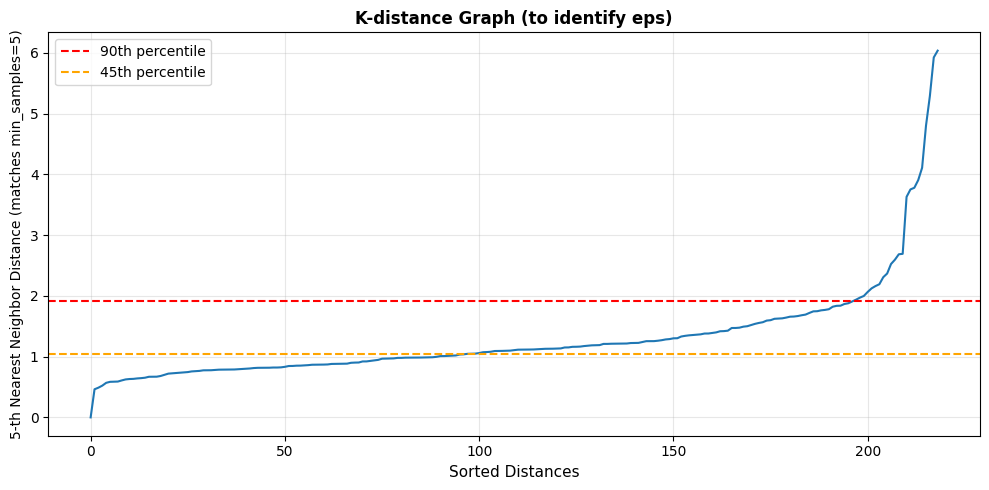

Suggested eps values: median=1.106, 45th=1.048, 90th=1.913


In [ ]:
# Calcular matriz de distancias para encontrar eps óptimo
distances = pairwise_distances(X)
k_distance = np.sort(distances[:, 4], axis=0)
# k=4 (min_samples default es k+1)
# Visualizar k-distance graph para elegir eps
plt.figure(figsize=(10, 5))
plt.plot(k_distance)
plt.xlabel('Sorted Distances', fontsize=11)
plt.ylabel('5-th Nearest Neighbor Distance (matches min_samples=5)')
plt.title('K-distance Graph (to identify eps)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.axhline(y=np.percentile(k_distance, 90), color='r', linestyle='--', label='90th percentile')
plt.axhline(y=np.percentile(k_distance, 45), color='orange', linestyle='--', label='45th percentile')
plt.legend()
plt.tight_layout()
plt.show()

# Sugerir eps basado en el gráfico
eps_90 = np.percentile(k_distance, 90)
eps_45 = np.percentile(k_distance, 45)
eps_median = np.median(k_distance)
print(f"Suggested eps values: median={eps_median:.3f}, 45th={eps_45:.3f}, 90th={eps_90:.3f}")

In [ ]:
eps_values_wide = np.linspace(eps_45, eps_90 * 2.5, 12)
min_samples_values_wide = [3, 5, 7, 10, 15]

dbscan_results_wide = []

for eps in eps_values_wide:
    for min_samples in min_samples_values_wide:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters >= 2 and n_noise < len(labels) * 0.3:
            try:
                sil = silhouette_score(X, labels)
            except:
                sil = np.nan

            dbscan_results_wide.append({
                'eps': round(eps, 3),
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'silhouette': sil,
                'labels': labels
            })

dbscan_wide_df = pd.DataFrame(dbscan_results_wide)

In [ ]:
if len(dbscan_wide_df) > 0:
    dbscan_wide_df = dbscan_wide_df.sort_values('silhouette', ascending=False)
    print("DBSCAN Wide Sweep — top 10 by silhouette:")
    print(dbscan_wide_df[['eps','min_samples','n_clusters','n_noise','silhouette']].head(10).to_string(index=False))

    # Best config with >= 3 clusters (more useful for recommendation)
    multi = dbscan_wide_df[dbscan_wide_df['n_clusters'] >= 3]
    if len(multi) > 0:
        best_multi = multi.iloc[0]
        print(f"\nBest DBSCAN with >= 3 clusters:")
        print(f"  eps={best_multi['eps']:.3f}  min_samples={int(best_multi['min_samples'])}")
        print(f"  n_clusters={int(best_multi['n_clusters'])}  noise={int(best_multi['n_noise'])}  silhouette={best_multi['silhouette']:.3f}")
    else:
        print("\nNo configuration found 3+ meaningful clusters — confirms DBSCAN is not suited for this space.")
else:
    print("No valid configurations found.")

DBSCAN Wide Sweep — top 10 by silhouette:
  eps  min_samples  n_clusters  n_noise  silhouette
1.727            3           2        6    0.600859

No configuration found 3+ meaningful clusters — confirms DBSCAN is not suited for this space.


The DBSCAN parameter sweep showed that the algorithm consistently favored a very coarse structure in the data. The best configuration (ε=1.727, min_samples = 3) achieved a high silhouette score (0.601), but produced only 2 clusters with very limited noise detection. When forcing more semantically useful solutions with 3 or more clusters, no stable configuration was found, indicating that the PCA space does not contain well-separated density-based regions. Instead, the city profiles appear to form gradual and overlapping transitions rather than compact density islands. Therefore, DBSCAN was considered unsuitable for generating meaningful multi-archetype city clusters in this recommendation setting, while centroid-based methods such as K-Means provided more interpretable segmentation.

##DBSCAN parameter sweep

In [ ]:
!pip install kneed

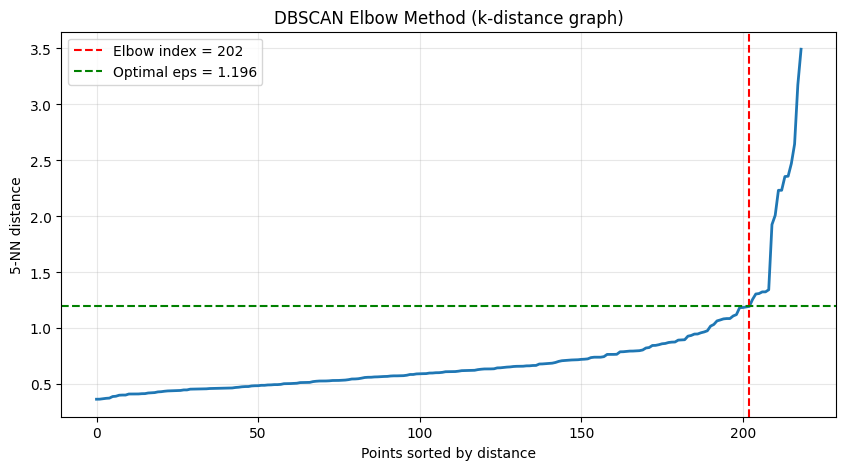

Optimal epsilon (eps): 1.196


In [ ]:
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
min_samples = 5

# -----------------------------
# Compute k-nearest neighbor distances
# -----------------------------
neighbors = NearestNeighbors(n_neighbors=min_samples)

neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

# distance to the k-th nearest neighbor
k_distances = np.sort(distances[:, min_samples - 1])

# -----------------------------
# Find elbow automatically
# -----------------------------
kneedle = KneeLocator(
    range(len(k_distances)),
    k_distances,
    curve='convex',
    direction='increasing'
)

optimal_eps = k_distances[kneedle.knee]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(k_distances, linewidth=2)

plt.axvline(
    kneedle.knee,
    color='red',
    linestyle='--',
    label=f'Elbow index = {kneedle.knee}'
)

plt.axhline(
    optimal_eps,
    color='green',
    linestyle='--',
    label=f'Optimal eps = {optimal_eps:.3f}'
)

plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-NN distance')
plt.title('DBSCAN Elbow Method (k-distance graph)')
plt.grid(alpha=0.3)
plt.legend()

plt.show()

print(f"Optimal epsilon (eps): {optimal_eps:.3f}")

In [ ]:
optimal_eps = 1.196

eps_values = np.linspace(optimal_eps * 0.75, optimal_eps * 1.35, 15)
min_samples_values = [3, 4, 5, 7, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1 and n_noise < len(labels) * 0.5:
          # Filter unreasonable results
            try:
                silhouette = silhouette_score(X, labels)
            except:
                silhouette = np.nan

            dbscan_results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'silhouette': silhouette,
                'model': dbscan,
                'labels': labels
            })

In [ ]:
dbscan_df = pd.DataFrame(dbscan_results)

if len(dbscan_df) > 0:
    dbscan_df = dbscan_df.sort_values('silhouette', ascending=False)
    print(f"\nDBSCAN Results (sorted by silhouette):")
    print(dbscan_df.head(10).to_string(index=False))

    best_dbscan = dbscan_df.iloc[0]
    print(f"\nBest DBSCAN configuration:")
    print(f"  eps: {best_dbscan['eps']:.3f}, min_samples: {int(best_dbscan['min_samples'])}")
    print(f"  Clusters: {int(best_dbscan['n_clusters'])}, Noise points: {int(best_dbscan['n_noise'])}")
    print(f"  Silhouette: {best_dbscan['silhouette']:.3f}")
else:
    print("\nNo suitable DBSCAN configurations found. Try adjusting parameter ranges.")


DBSCAN Results (sorted by silhouette):
     eps  min_samples  n_clusters  n_noise  silhouette                                                     model                                                                                                                                                                                                                                                                                                                labels
1.409571            3           2        7    0.598921 DBSCAN(eps=np.float64(1.4095714285714287), min_samples=3) [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0, ...]
1.460829            3           2        7    0.598921 DBSCAN(eps=np.float64(1.4608285714285714), min_samples=3) [

The k-distance graph identified an estimated optimal ε≈1.196, which was then used to explore nearby DBSCAN configurations. Across the parameter sweep, the best solutions consistently converged to the same structure: 2 clusters with very few noise points and a high silhouette score (~0.599). This indicates that the PCA space contains one dominant density separation rather than multiple compact density-based groups. The stability of the results across several ε values suggests that the detected structure is robust, but also confirms that DBSCAN mainly captures a broad binary division of cities instead of finer commercial archetypes. Therefore, while DBSCAN demonstrates strong statistical cohesion, it lacks the granularity required for recommendation-oriented urban profiling compared to K-Means.

#CLUSTER PROFILE ANALYSIS (K-Means with k selected)
Caracterizar cada cluster usando los 5 PCs principales


In [ ]:
# Crear dataframe con clusters
cluster_df = pd.DataFrame({
    'city': city_names,
    'cluster': kmeans_labels,
    'PC1': X[:, 0],
    'PC2': X[:, 1],
    'PC3': X[:, 2],
    'PC4': X[:, 3],
    'PC5': X[:, 4]
})

# Agregar features originales para contexto
for col in ['n_businesses', 'avg_stars', 'personality__food_dining',
            'personality__nightlife_social', 'personality__beauty_wellness']:
    if col in cities_orig_filtered.columns:
        cluster_df[col] = cities_orig_filtered[col].values

print(f"\n{'='*100}")
print(f"CLUSTER PROFILES (K-Means, k={SEMANTIC_K})")
print(f"{'='*100}")
for cluster_id in sorted(cluster_df['cluster'].unique()):
    cluster_cities = cluster_df[cluster_df['cluster'] == cluster_id]

    print(f"\n{'─'*100}")
    print(f"CLUSTER {cluster_id} | {len(cluster_cities)} cities")
    print(f"{'─'*100}")

    # Centroid analysis
    print(f"\nCentroid values (PC space):")

    print(f"  PC1 (Casual family dining): "
          f"{cluster_cities['PC1'].mean():+.3f} "
          f"(σ={cluster_cities['PC1'].std():.3f})")

    print(f"  PC2 (Upscale dining & nightlife): "
          f"{cluster_cities['PC2'].mean():+.3f} "
          f"(σ={cluster_cities['PC2'].std():.3f})")

    print(f"  PC3 (Wellness & accessible lifestyle): "
          f"{cluster_cities['PC3'].mean():+.3f} "
          f"(σ={cluster_cities['PC3'].std():.3f})")

    print(f"  PC4 (Urban activity & commercial engagement): "
          f"{cluster_cities['PC4'].mean():+.3f} "
          f"(σ={cluster_cities['PC4'].std():.3f})")

    print(f"  PC5 (Brunch & upscale social dining): "
          f"{cluster_cities['PC5'].mean():+.3f} "
          f"(σ={cluster_cities['PC5'].std():.3f})")

    # Size & quality
    if 'n_businesses' in cluster_cities.columns:
        print(f"\nSize & Quality:")
        print(f"  Avg businesses: {cluster_cities['n_businesses'].mean():.0f}")
        print(f"  Avg rating: {cluster_cities['avg_stars'].mean():.2f}")

    # Top cities in cluster
    print(f"\nTop 5 representative cities:")
    top_cities = cluster_cities.nlargest(5, 'n_businesses')[['city', 'n_businesses']].values
    for i, (city, n_biz) in enumerate(top_cities, 1):
        print(f"  {i}. {city} ({int(n_biz)} businesses)")



CLUSTER PROFILES (K-Means, k=4)

────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 0 | 71 cities
────────────────────────────────────────────────────────────────────────────────────────────────────

Centroid values (PC space):
  PC1 (Casual family dining): +0.487 (σ=0.408)
  PC2 (Upscale dining & nightlife): -0.537 (σ=0.347)
  PC3 (Wellness & accessible lifestyle): -0.209 (σ=0.296)
  PC4 (Urban activity & commercial engagement): +0.042 (σ=0.295)
  PC5 (Brunch & upscale social dining): -0.198 (σ=0.200)

Size & Quality:
  Avg businesses: 185
  Avg rating: 3.39

Top 5 representative cities:
  1. New Port Richey (604 businesses)
  2. Kenner (584 businesses)
  3. Bensalem (454 businesses)
  4. Smyrna (366 businesses)
  5. Newark (359 businesses)

────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 1 | 9 cities
──────────────────────────────────────────────────────────────────

Cluster 0 represents mainstream suburban dining ecosystems characterized by strong casual and family-oriented restaurant culture (high PC1) but relatively low upscale nightlife and brunch activity (negative PC2 and PC5). Representative cities such as New Port Richey, Kenner, and Bensalem suggest commercially active but predominantly practical and everyday dining environments with moderate business density and lower social sophistication.

Cluster 1 captures highly distinctive tourism- and leisure-oriented cities with extremely high scores on casual dining, upscale nightlife, and wellness-related commercial infrastructure. Beach-oriented cities such as St. Pete Beach, Madeira Beach, Clearwater Beach, and Treasure Island dominate this cluster, indicating specialized urban-commercial profiles associated with hospitality, tourism, and socially active leisure economies.

Cluster 2 represents affluent and lifestyle-oriented suburban hubs with balanced positive scores across casual dining, upscale dining, and wellness/accessibility dimensions. Cities such as Carmel, Goleta, Fishers, and Dunedin exhibit commercially diverse and socially active environments with relatively high ratings and stronger premium lifestyle characteristics than Cluster 0.

Cluster 3 contains larger and more generalized urban-commercial ecosystems with lower emphasis on casual dining identity (negative PC1) but relatively balanced values across the remaining dimensions. Representative cities such as Meridian, Brandon, Largo, and Cherry Hill suggest broad commercial coverage and mixed urban lifestyles without strongly specialized nightlife or brunch-oriented characteristics.

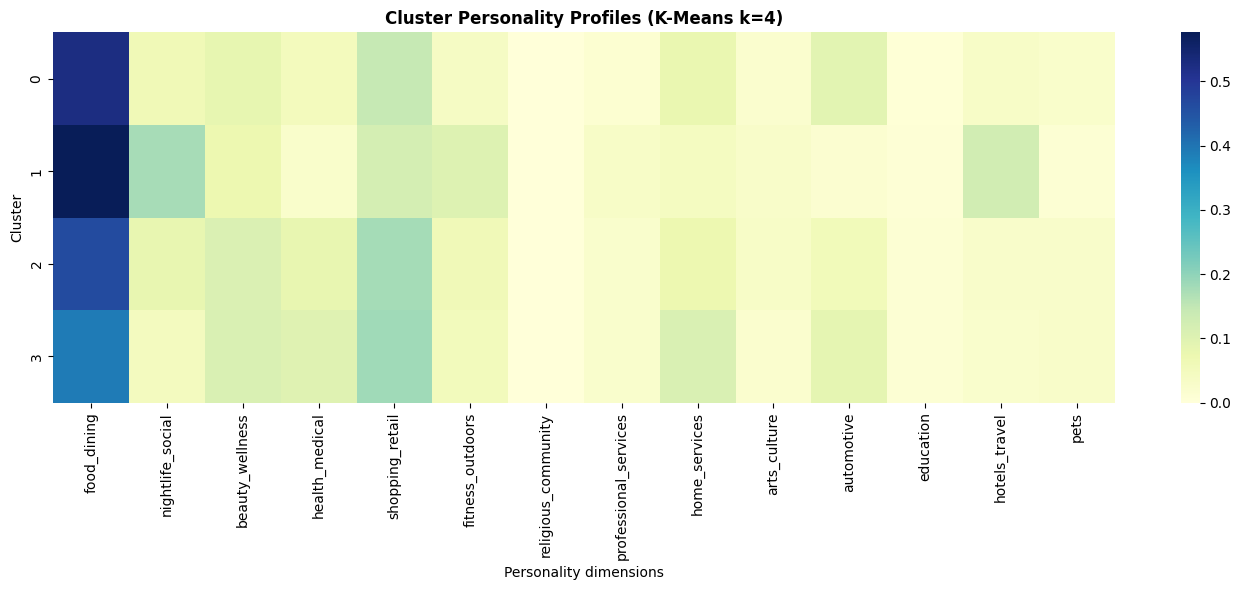

In [ ]:
# Features originales de personalidad (no PCA) para interpretar clusters
personality_cols = [c for c in cities_orig_filtered.columns if c.startswith('personality__')]

profile_df = cities_orig_filtered[['city'] + personality_cols].copy()
profile_df['cluster'] = kmeans_labels

centroids_profile = profile_df.groupby('cluster')[personality_cols].mean()

# opcional: nombres más limpios
centroids_profile.columns = [c.replace('personality__','') for c in centroids_profile.columns]

plt.figure(figsize=(14,6))
sns.heatmap(centroids_profile, cmap='YlGnBu', annot=False)
plt.title(f'Cluster Personality Profiles (K-Means k={SEMANTIC_K})', fontsize=12, fontweight='bold')
plt.xlabel('Personality dimensions')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

The personality-profile heatmap complements the PCA cluster interpretation by showing that all clusters are strongly dominated by the food_dining dimension, confirming that restaurant culture is the central organizing structure of the urban commercial space. However, important secondary differences emerge across clusters. Cluster 1 exhibits the strongest nightlife_social and hotels_travel signals, reinforcing its tourism- and leisure-oriented identity. Cluster 2 shows elevated beauty_wellness, shopping_retail, and fitness_outdoors values, consistent with affluent lifestyle-oriented suburban environments. In contrast, Cluster 0 reflects more practical and routine-oriented commercial ecosystems with weaker lifestyle specialization, while Cluster 3 presents a broader and more balanced urban-commercial profile without strong dominance in any single personality dimension.

/tmp/ipykernel_1474/2788112284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_feats.values, y=top_feats.index, palette='viridis')


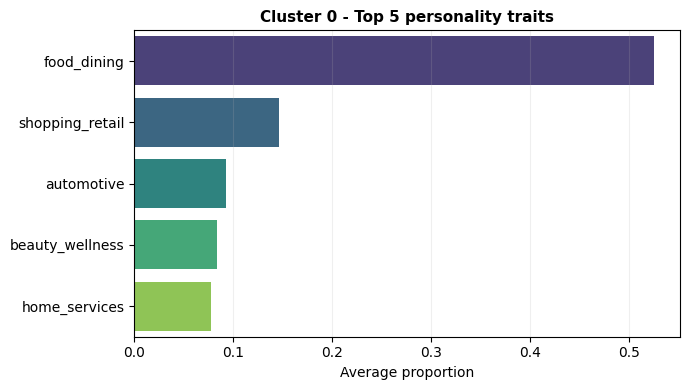

/tmp/ipykernel_1474/2788112284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_feats.values, y=top_feats.index, palette='viridis')


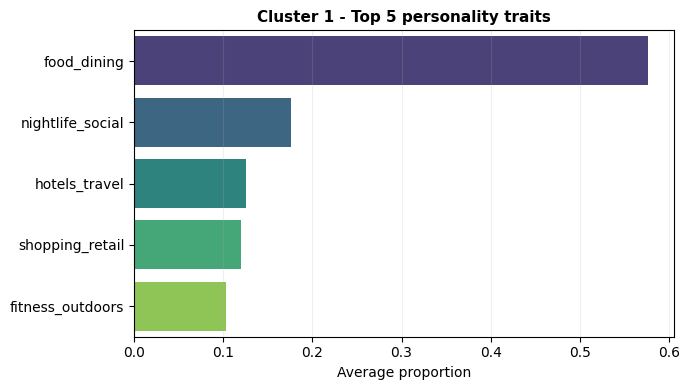

/tmp/ipykernel_1474/2788112284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_feats.values, y=top_feats.index, palette='viridis')


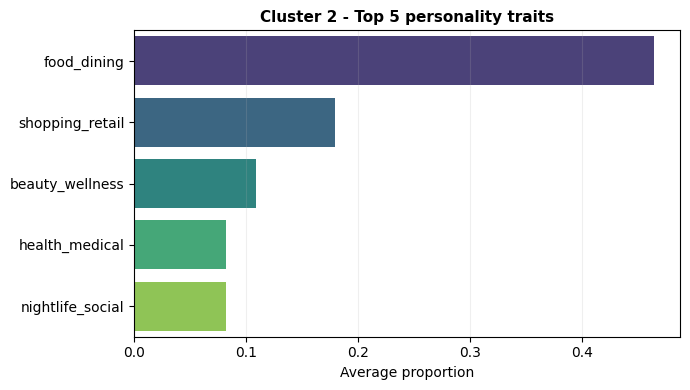

/tmp/ipykernel_1474/2788112284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_feats.values, y=top_feats.index, palette='viridis')


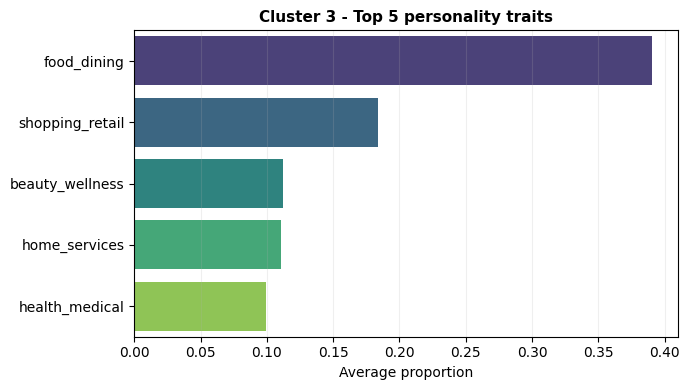

In [ ]:
top_n = 5
for cl in centroids_profile.index:
    top_feats = centroids_profile.loc[cl].sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(7,4))
    sns.barplot(x=top_feats.values, y=top_feats.index, palette='viridis')
    plt.title(f'Cluster {cl} - Top {top_n} personality traits', fontsize=11, fontweight='bold')
    plt.xlabel('Average proportion')
    plt.ylabel('')
    plt.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

These graphs show the compositions of every cluster with the top 5 %

# 2D clusters (PC1 vs PC2)

Visualization using kmeans

In [ ]:
from scipy.spatial.distance import cdist

important_cities = []

# Distance from every point to every centroid
distances = cdist(X, kmeans.cluster_centers_)

for cluster_id in range(SEMANTIC_K):

    # Cities belonging to this cluster
    cluster_mask = (kmeans_labels == cluster_id)
    cluster_indices = np.where(cluster_mask)[0]

    # Distances to its own centroid
    cluster_distances = distances[cluster_indices, cluster_id]

    # Closest city to centroid
    closest_idx = cluster_indices[np.argmin(cluster_distances)]
    city_name = city_names.iloc[closest_idx]
    important_cities.append(city_name)

print("Representative cities:")
print(important_cities)

Representative cities:
['Bensalem', 'Treasure Island', 'Lambertville', 'Spring Hill']


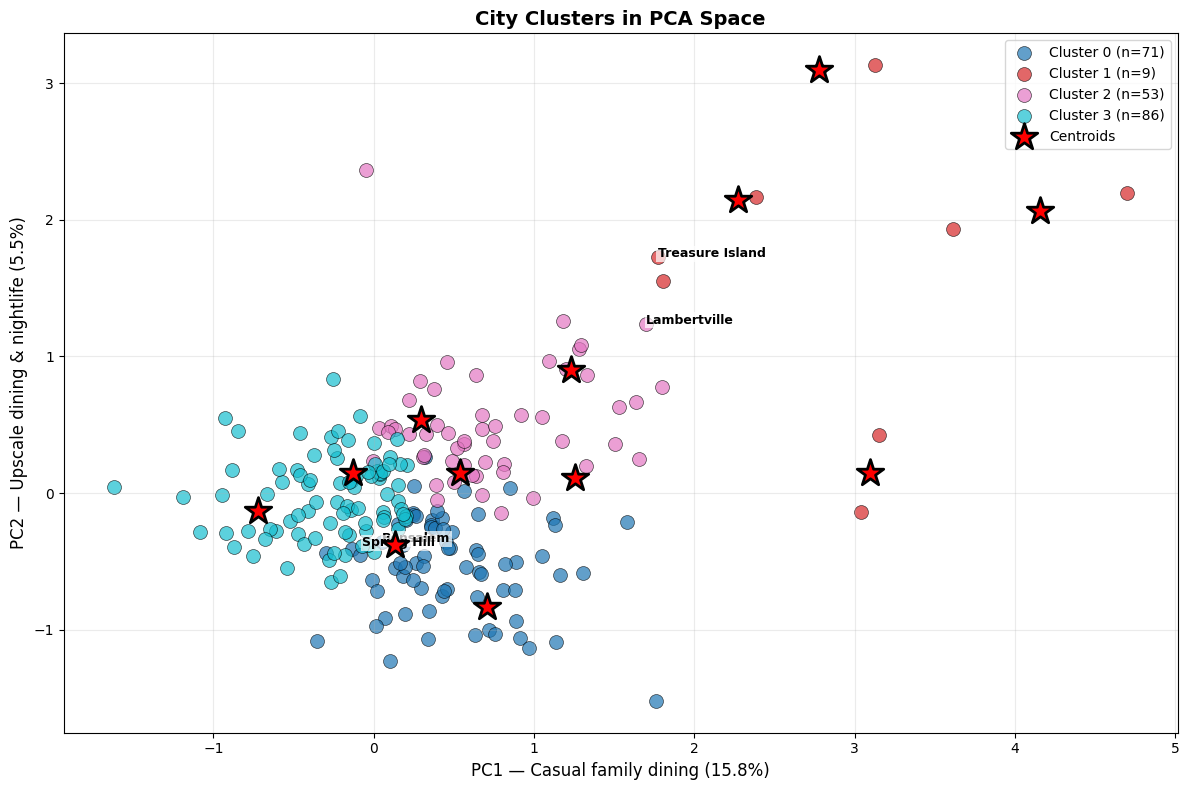

In [ ]:
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, SEMANTIC_K))

# Scatter plot by cluster
for cluster_id in range(SEMANTIC_K):

    mask = kmeans_labels == cluster_id

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        c=[colors[cluster_id]],
        s=100,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5,
        label=f'Cluster {cluster_id} (n={mask.sum()})'
    )
for city in important_cities:
    matches = city_names[city_names == city]

    if len(matches) > 0:

        idx = matches.index[0]

        plt.text(
            X[idx, 0],
            X[idx, 1],
            city,
            fontsize=9,
            fontweight='bold',
            bbox=dict(
                facecolor='white',
                alpha=0.7,
                edgecolor='none',
                pad=1
            )
        )

centroids = kmeans.cluster_centers_

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=400, marker='*',
           edgecolors='black', linewidth=2, label='Centroids', zorder=5)

plt.xlabel('PC1 — Casual family dining (15.8%)', fontsize=12)
plt.ylabel('PC2 — Upscale dining & nightlife (5.5%)', fontsize=12)

plt.title(
    'City Clusters in PCA Space',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

The PCA cluster projection shows a clear semantic separation between urban-commercial archetypes identified by K-Means. Cluster 0 concentrates in the lower-right region of the space, representing cities with strong casual dining identity but lower upscale nightlife activity, while Cluster 2 occupies higher PC2 values, indicating more upscale and socially active commercial environments. Cluster 1 appears as a small but highly differentiated group positioned far from the central mass of cities, reflecting specialized tourism- and nightlife-oriented destinations such as Treasure Island. In contrast, Cluster 3 remains closer to the center-left region, representing more generalized urban-commercial ecosystems with less extreme dining or nightlife specialization. Representative cities were selected as the closest points to each cluster centroid, allowing the most characteristic city profiles to summarize the latent commercial identity of each cluster.

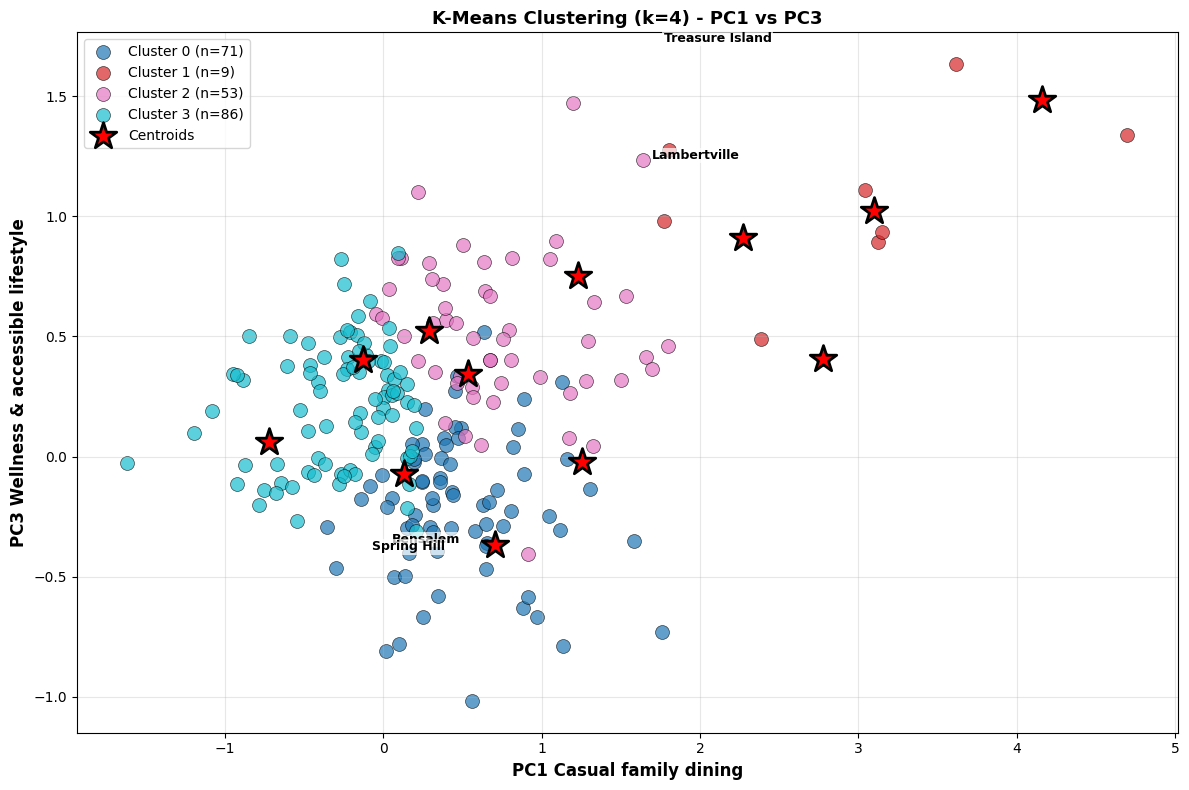

In [ ]:
# Visualización de clusters en 2D (PC1 vs PC3)
plt.figure(figsize=(12, 8))

for cluster_id in range(SEMANTIC_K):
    mask = kmeans_labels == cluster_id
    plt.scatter(X[mask, 0], X[mask, 2], c=[colors[cluster_id]],
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5,
               label=f'Cluster {cluster_id} (n={mask.sum()})')

for city in important_cities:
    matches = city_names[city_names == city]

    if len(matches) > 0:

        idx = matches.index[0]

        plt.text(
            X[idx, 0],
            X[idx, 1],
            city,
            fontsize=9,
            fontweight='bold',
            bbox=dict(
                facecolor='white',
                alpha=0.7,
                edgecolor='none',
                pad=1
            )
        )
plt.scatter(centroids[:, 0], centroids[:, 2], c='red', s=400, marker='*',
           edgecolors='black', linewidth=2, label='Centroids', zorder=5)

plt.xlabel('PC1 Casual family dining', fontsize=12, fontweight='bold')
plt.ylabel('PC3 Wellness & accessible lifestyle', fontsize=12, fontweight='bold')
plt.title(f'K-Means Clustering (k={SEMANTIC_K}) - PC1 vs PC3', fontsize=13, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This highlights how cities with similar casual dining intensity (PC1) can still diverge strongly in wellness-oriented and accessibility-related commercial identity (PC3). Cluster 0 concentrates in lower PC3 values, representing more conventional casual dining ecosystems with weaker wellness/accessibility signals, while Cluster 3 shifts upward on PC3, indicating cities with stronger wellness, bike-friendly, appointment-based, and accessibility-oriented commercial environments. Cluster 2 occupies intermediate-to-high values on both axes, reflecting balanced cities that combine strong dining activity with lifestyle and retail sophistication. Cluster 1 remains highly separated on the far-right side of PC1, confirming the presence of specialized destination-like cities with unusually strong commercial and tourism-oriented profiles, such as Treasure Island.

#FAILURE ANALYSIS - Silhouette scores por city

## Cities with lowest silhouette (probably dont fit best into their assigned clusters)

In [ ]:
silhouette_scores = silhouette_samples(X, kmeans_labels)
cluster_df['silhouette'] = silhouette_scores

print(f"\n{'='*100}")
print(f"FAILURE ANALYSIS - Cities with Poor Cluster Fit")
print(f"{'='*100}")

# Ciudades con silhouette negativo (malas encajadas)
poor_fit = cluster_df[cluster_df['silhouette'] < 0].sort_values('silhouette')
print(f"\nCities with NEGATIVE silhouette (wrong cluster): {len(poor_fit)}")
if len(poor_fit) > 0:
    print("\nTop 10 worst fits:")
    print(poor_fit[['city', 'cluster', 'silhouette', 'n_businesses']].head(10).to_string(index=False))


FAILURE ANALYSIS - Cities with Poor Cluster Fit

Cities with NEGATIVE silhouette (wrong cluster): 23

Top 10 worst fits:
           city  cluster  silhouette  n_businesses
       Narberth        2   -0.122138           113
     Oro Valley        2   -0.113579           286
University City        1   -0.112788            98
          Eagle        2   -0.075528           289
    Nolensville        2   -0.074000            93
      Bryn Mawr        2   -0.072948           286
   Mount Juliet        0   -0.071664           281
       O'Fallon        2   -0.063054           153
          Wayne        2   -0.060006           375
New Port Richey        0   -0.053131           604


In [ ]:
# Ciudades with lower positive silhouette(limítrofes)
low_fit = cluster_df[(cluster_df['silhouette'] >= 0) & (cluster_df['silhouette'] < 0.2)].sort_values('silhouette')
print(f"\n\nCities with LOW positive silhouette (0 < score < 0.2): {len(low_fit)}")
if len(low_fit) > 0:
    print("These cities are ambiguous/borderline:")
    print(low_fit[['city', 'cluster', 'silhouette', 'n_businesses']].head(15).to_string(index=False))



Cities with LOW positive silhouette (0 < score < 0.2): 75
These cities are ambiguous/borderline:
            city  cluster  silhouette  n_businesses
      St. Albert        0    0.007521            70
         Clayton        1    0.013059           211
         Harahan        2    0.013826           157
     Valley Park        0    0.014004            80
       Wynnewood        2    0.019507            86
    Phoenixville        2    0.026826           365
          Marana        2    0.029981           102
     Haddonfield        2    0.033624           183
           Media        2    0.043083           372
     Maple Shade        0    0.043359           148
    Edwardsville        2    0.045100           274
       Hermitage        0    0.052404           267
Fairview Heights        3    0.053377           241
      Brookhaven        0    0.053953            72
          Berlin        0    0.061675            99


In [ ]:
# cities with high silhouette alto (bien encajadas)
good_fit = cluster_df[cluster_df['silhouette'] > 0.45].sort_values('silhouette', ascending=False)
print(f"\n\nCities with HIGH silhouette (> 0.45): {len(good_fit)}")
if len(good_fit) > 0:
    print("These cities fit their cluster well:")
    print(good_fit[['city', 'cluster', 'silhouette', 'n_businesses']].head(10).to_string(index=False))



Cities with HIGH silhouette (> 0.45): 3
These cities fit their cluster well:
       city  cluster  silhouette  n_businesses
       Lutz        3    0.474577           591
Southampton        3    0.467443           209
    Trinity        3    0.461159           108


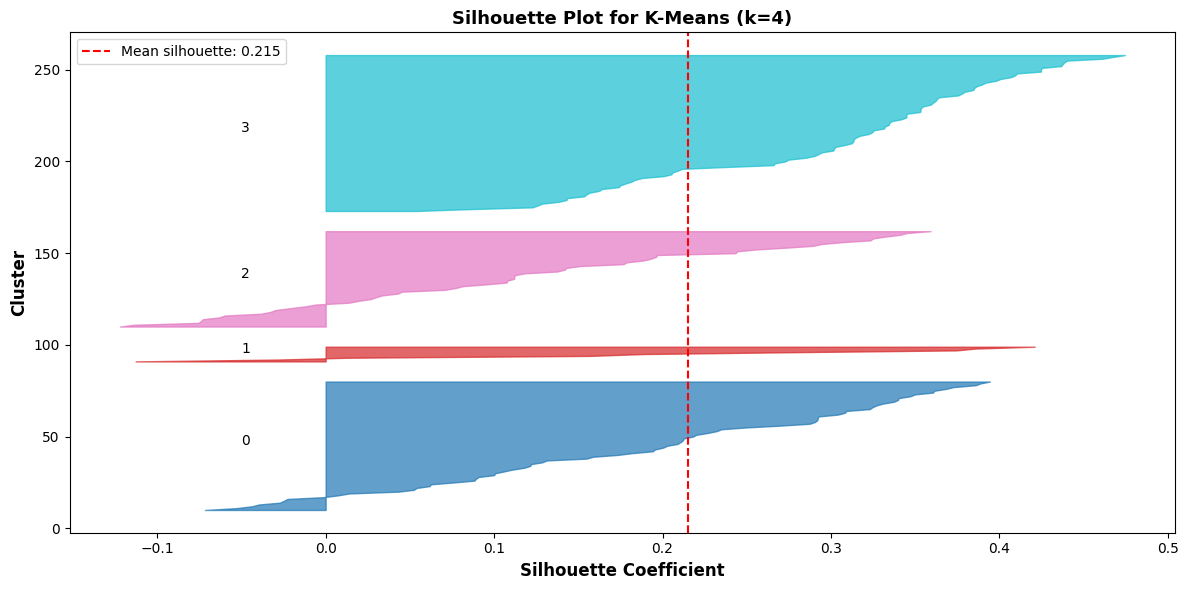

In [ ]:
# Visualizar silhouette per cluster
fig, ax = plt.subplots(figsize=(12, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, SEMANTIC_K))

for i in range(SEMANTIC_K):
    cluster_silhouette = silhouette_scores[kmeans_labels == i]
    cluster_silhouette.sort()

    size_cluster = cluster_silhouette.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette,
                    facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X, kmeans_labels), color="red", linestyle="--", label=f"Mean silhouette: {silhouette_score(X, kmeans_labels):.3f}")
ax.set_xlabel("Silhouette Coefficient", fontsize=12, fontweight='bold')
ax.set_ylabel("Cluster", fontsize=12, fontweight='bold')
ax.set_title(f'Silhouette Plot for K-Means (k={SEMANTIC_K})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

The silhouette plot for K-Means with k=4 shows a relatively weak cluster structure, with an average silhouette score of 0.215. This indicates that there clusters overlapping. Cluster 3 appears to be the most cohesive and best defined, as many of its samples have higher silhouette values. In contrast, clusters 0 and 2 contain several points with silhouette values close to zero and some negative values, suggesting ambiguous or potentially incorrect assignments. Overall, the plot suggests that k=4 does not provide a strong clustering solution, however as we are working with a recommendation system choosing k=2 wouldn't provide much insight since it would be separating clusters based on most popular rather than the cities personalities

##kmeans vs dbscan

/tmp/ipykernel_1474/257403569.py:41: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[1].scatter(X[mask, 0], X[mask, 1], c=[color],


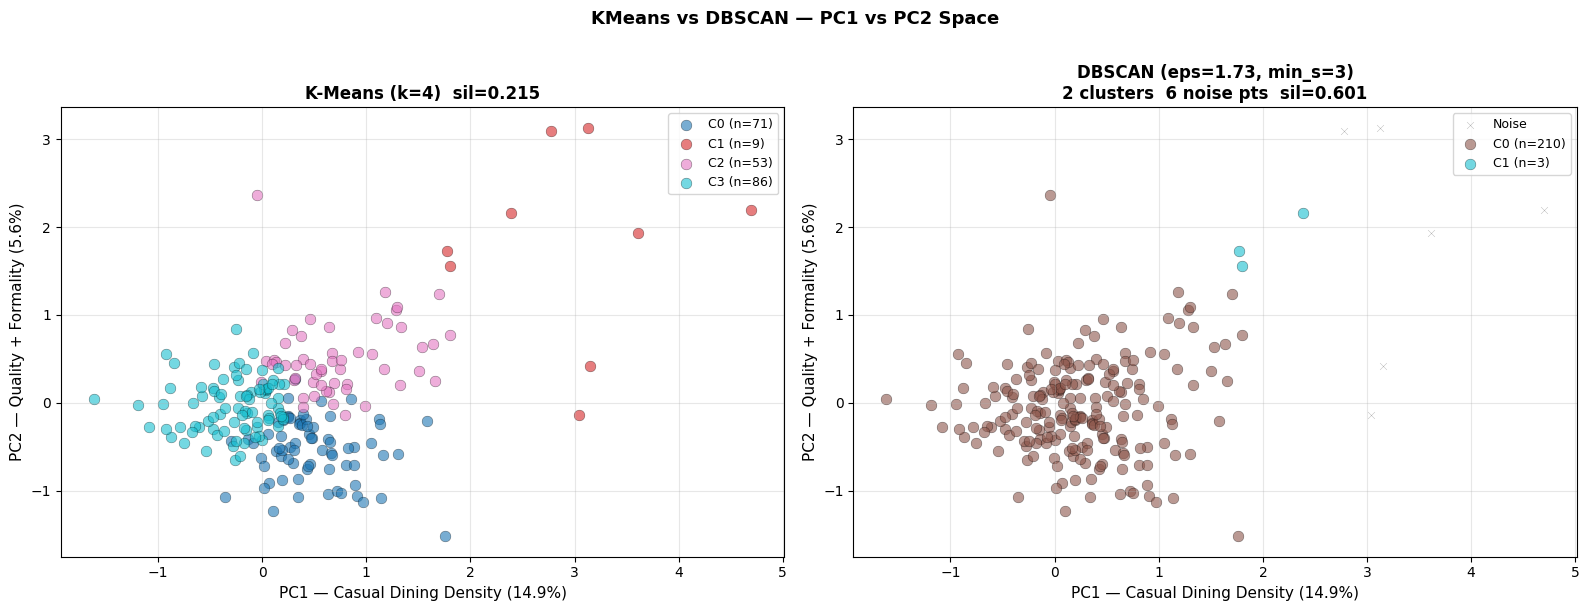

ALGORITHM DECISION SUMMARY
KMeans k=4:  silhouette=0.215  |  4 clusters  |  0 noise pts
Best DBSCAN:    silhouette=0.601  |  2 clusters  |  6 noise pts

Conclusion: KMeans k=4 selected for the recommendation system.
Reasons:
  1. DBSCAN in PCA space finds convex clusters — same geometry as KMeans.
  2. DBSCAN collapses to k=2 or produces noise-heavy solutions at useful granularity.
  3. KMeans assigns every city to a cluster — required for recommendation.
  4. Both algorithms agree on the main split, validating cluster stability.


In [ ]:
# ── Side by side scatter: KMeans k=4 vs best DBSCAN ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: KMeans k=4
colors_km = plt.cm.tab10(np.linspace(0, 1, SEMANTIC_K))
for cluster_id in range(SEMANTIC_K):
    mask = kmeans_labels == cluster_id
    axes[0].scatter(X[mask, 0], X[mask, 1], c=[colors_km[cluster_id]],
                    s=60, alpha=0.6, edgecolors='black', linewidth=0.3,
                    label=f'C{cluster_id} (n={mask.sum()})')
axes[0].set_xlabel('PC1 — Casual Dining Density (14.9%)', fontsize=11)
axes[0].set_ylabel('PC2 — Quality + Formality (5.6%)', fontsize=11)
axes[0].set_title(f'K-Means (k={SEMANTIC_K})  sil={kmeans_df.loc[kmeans_df["k"]==SEMANTIC_K,"silhouette"].values[0]:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: Best DBSCAN (uses wider sweep if available, else original)
if len(dbscan_wide_df) > 0:
    best_labels = dbscan_wide_df.iloc[0]['labels']
    best_eps    = dbscan_wide_df.iloc[0]['eps']
    best_ms     = int(dbscan_wide_df.iloc[0]['min_samples'])
    best_sil    = dbscan_wide_df.iloc[0]['silhouette']
    best_nc     = int(dbscan_wide_df.iloc[0]['n_clusters'])
    best_noise  = int(dbscan_wide_df.iloc[0]['n_noise'])
else:
    best_labels = best_dbscan['labels']
    best_eps    = best_dbscan['eps']
    best_ms     = int(best_dbscan['min_samples'])
    best_sil    = best_dbscan['silhouette']
    best_nc     = int(best_dbscan['n_clusters'])
    best_noise  = int(best_dbscan['n_noise'])

unique_labels = sorted(set(best_labels))
colors_db = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))

for j, lbl in enumerate(unique_labels):
    mask = np.array(best_labels) == lbl
    color = 'black' if lbl == -1 else colors_db[j]
    label_name = 'Noise' if lbl == -1 else f'C{lbl} (n={mask.sum()})'
    axes[1].scatter(X[mask, 0], X[mask, 1], c=[color],
                    s=60 if lbl != -1 else 25,
                    alpha=0.6 if lbl != -1 else 0.3,
                    edgecolors='black', linewidth=0.3,
                    marker='o' if lbl != -1 else 'x',
                    label=label_name)

axes[1].set_xlabel('PC1 — Casual Dining Density (14.9%)', fontsize=11)
axes[1].set_ylabel('PC2 — Quality + Formality (5.6%)', fontsize=11)
axes[1].set_title(
    f'DBSCAN (eps={best_eps:.2f}, min_s={best_ms})\n'
    f'{best_nc} clusters  {best_noise} noise pts  sil={best_sil:.3f}',
    fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('KMeans vs DBSCAN — PC1 vs PC2 Space', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Decision summary
print("=" * 70)
print("ALGORITHM DECISION SUMMARY")
print("=" * 70)
print(f"KMeans k={SEMANTIC_K}:  silhouette={kmeans_df.loc[kmeans_df['k']==SEMANTIC_K,'silhouette'].values[0]:.3f}  |  {SEMANTIC_K} clusters  |  0 noise pts")
print(f"Best DBSCAN:    silhouette={best_sil:.3f}  |  {best_nc} clusters  |  {best_noise} noise pts")
print()
print("Conclusion: KMeans k=4 selected for the recommendation system.")
print("Reasons:")
print("  1. DBSCAN in PCA space finds convex clusters — same geometry as KMeans.")
print("  2. DBSCAN collapses to k=2 or produces noise-heavy solutions at useful granularity.")
print("  3. KMeans assigns every city to a cluster — required for recommendation.")
print("  4. Both algorithms agree on the main split, validating cluster stability.")

PCA-transformed city space does not contain strongly separated high-density regions. This suggests that the data distribution is relatively continuous rather than composed of compact dense clusters. Consequently, centroid-based clustering (K-Means) provided more interpretable and stable groupings for downstream city-profile analysis.

DBSCAN was tested as an alternative density-based method, but the PCA-transformed city space does not show clearly separated high-density regions.
In our experiments, DBSCAN either collapsed into very coarse solutions (few clusters) or produced noise-heavy outputs at finer settings.
Therefore, K-Means (k=4) was retained as the final approach because it provides more stable and interpretable city archetypes for recommendation analysis.

###Save clusters info

In [ ]:
cluster_df.to_parquet('city_clusters.parquet', index=False)
#Drop the 'model' column from kmeans_df before saving, as Parquet cannot serialize KMeans objects.
kmeans_df.drop(columns=['model'], errors='ignore').to_parquet('kmeans_validation.parquet', index=False)
if len(dbscan_df) > 0:
    # Similarly, drop the 'model' and 'labels' columns from dbscan_df
    # if they are present and contain unserializable objects.
    dbscan_df.drop(columns=['model', 'labels'], errors='ignore').to_parquet('dbscan_validation.parquet', index=False)

print("\n" + "="*100)
print("CLUSTERING SUMMARY")
print("="*100)
print(f"\nDataset filtered: n_businesses >= {MIN_BUSINESSES} → {len(cluster_df)} cities")
print(f"PCA space: 28 components")
print(f"\nK-Means optimal clusters: k = {SEMANTIC_K}")
print(f"  Silhouette score: {best_kmeans_result['silhouette']:.3f}")
print(f"  Inertia: {best_kmeans_result['inertia']:.1f}")
print(f"  Davies-Bouldin: {best_kmeans_result['davies_bouldin']:.3f}")

if len(dbscan_df) > 0:
    print(f"\nDBSCAN best result:")
    print(f"  Clusters: {int(best_dbscan['n_clusters'])}, Noise: {int(best_dbscan['n_noise'])}")
    print(f"  Silhouette: {best_dbscan['silhouette']:.3f}")

print(f"\nCluster distribution:")
for cluster_id in sorted(cluster_df['cluster'].unique()):
    count = (cluster_df['cluster'] == cluster_id).sum()
    pct = count / len(cluster_df) * 100
    mean_sil = cluster_df[cluster_df['cluster'] == cluster_id]['silhouette'].mean()
    print(f"  Cluster {cluster_id}: {count:3d} cities ({pct:5.1f}%) | mean silhouette: {mean_sil:+.3f}")

print(f"\nFiles saved:")
print(f"  - city_clusters.parquet")
print(f"  - kmeans_validation.parquet")
if len(dbscan_df) > 0:
    print(f"  - dbscan_validation.parquet")

Cluster distribution shows how cities are proportionally assigned across the four K-Means groups: 32.4%, 4.1%, 24.2%, and 39.3%.
These percentages represent group size (not model accuracy), while mean silhouette per cluster indicates internal cohesion.
Cluster 3 appears the most compact and consistent, while clusters with lower mean silhouette suggest more overlap and less clearly separated city profiles.